In [1]:
#imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from timm.data.mixup import Mixup
from timm.scheduler.cosine_lr import CosineLRScheduler
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import autoaugment
from tqdm import tqdm

/home/devika/personal/assignment-5-devika-bej/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Question 1

## Load Data

In [2]:
train_transform = torchvision.transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    autoaugment.AutoAugment(autoaugment.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.25)
])

test_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='../q1/data', train=True, download=True, transform=train_transform)
train_size = int(0.9 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])
valset.dataset.transform = test_transform
testset = torchvision.datasets.CIFAR10(root='../q1/data', train=False, download=True, transform=test_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=32, shuffle=False)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

## Model

### Embedding

In [3]:
class Embedding(nn.Module):
    def __init__(self, in_dim, patch_size = 4, embedding = "1d", image_size = 32):
        super(Embedding, self).__init__()
        self.in_dim = in_dim
        self.image_size = image_size
        self.patch_size = patch_size
        self.clstoken = nn.Parameter(torch.randn(1, 1, in_dim))
        self.embedding = embedding
        self.projection = nn.Linear(3 * patch_size * patch_size, self.in_dim)
        if embedding == "1d":
            self.pos_enc = nn.Parameter(torch.randn(1, 1 + (image_size // patch_size) ** 2, in_dim))
        elif embedding == "2d":
            self.row_enc = nn.Parameter(torch.randn(1, image_size // patch_size, in_dim))
            self.col_enc = nn.Parameter(torch.randn(1, image_size // patch_size, in_dim))
        elif embedding == "sin":
            max_len = 1 + (image_size // patch_size) ** 2
            pos_code = torch.zeros(max_len, in_dim)
            pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
            scale = torch.exp(torch.arange(0, in_dim, 2, dtype=torch.float) * -(torch.log(torch.tensor(10000)) / in_dim))
            pos_code[:, 0::2] = torch.sin(pos * scale)
            pos_code[:, 1::2] = torch.cos(pos * scale)
            self.register_buffer('pos_code', pos_code.unsqueeze(0))
        
    def generate_patches(self, images):
        batch_size, channels, h, w = images.shape
        self.channels = channels
        patches = images.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(batch_size, channels, -1, self.patch_size, self.patch_size)
        patches = patches.permute(0, 2, 1, 3, 4)
        return patches
    
    def patch_to_embed(self, patches):
        batch_size, num_patches, _, _, _ = patches.size()
        init_vector_size = self.channels * self.patch_size * self.patch_size
        tokens = patches.reshape((batch_size, num_patches, init_vector_size))
        return tokens
    
    def forward(self, x):
        x = self.projection(x)
        batch_size, num_patches, token_size = x.size()
        clstoken = self.clstoken.expand(batch_size, -1, -1)
        y = torch.cat((clstoken, x), dim=1)
        if self.embedding == "1d":
            y = y + self.pos_enc
        elif self.embedding == "2d":
            grid_size = self.image_size // self.patch_size
            patch = y[:, 1:, :]
            patch = patch.view(batch_size, grid_size, grid_size, token_size)
            position = self.row_enc[:, :, None, :] + self.col_enc[:, :, None, :]
            position = position.expand(batch_size, -1, -1, -1)
            patch = patch + position
            patch = patch.view(batch_size, -1, token_size)
            y = torch.cat((clstoken, patch), dim=1)
        elif self.embedding == "sin":
            seq_len = y.size(1)
            y = y + self.pos_code[:, :seq_len]
        elif self.embedding == "none":
            pass
        return y

### MHA

In [4]:
class MultiHeadDiffAttention(nn.Module):
    def __init__(self, in_dim, num_heads, dropout = 0.1):
        super(MultiHeadDiffAttention, self).__init__()
        self.in_dim = in_dim
        self.num_heads = num_heads
        self.sub_dim = torch.tensor(in_dim // num_heads)
        
        self.dropout = nn.Dropout(dropout)
        
        self.query_1 = nn.Linear(in_dim, in_dim)
        self.key_1 = nn.Linear(in_dim, in_dim)
        
        self.query_2 = nn.Linear(in_dim, in_dim)
        self.key_2 = nn.Linear(in_dim, in_dim)
        
        self.value = nn.Linear(in_dim, in_dim)
        self.lambda_param = nn.Parameter(torch.randn(1))
        self.out = nn.Linear(in_dim, in_dim)
        self.norm = nn.GroupNorm(num_heads, in_dim)
        
    def attention_score(self, query_val_1, key_val_1, query_val_2, key_val_2, value_val):
        # each has - batch_size x seq_len x num_heads x sub_dim
        score_1 = torch.matmul(query_val_1, key_val_1.transpose(-2, -1)) / torch.sqrt(self.sub_dim)
        score_2 = torch.matmul(query_val_2, key_val_2.transpose(-2, -1)) / torch.sqrt(self.sub_dim)
        # score - batch_size x seq_len x num_heads x num_heads (if num_heads > sub_dim)
        score_1 = torch.softmax(score_1, dim=-1)
        score_2 = torch.softmax(score_2, dim=-1)
        score_1 = self.dropout(score_1)
        score_2 = self.dropout(score_2)
        score = score_1 - self.lambda_param * score_2
        score = torch.matmul(score, value_val)
        return score
    
    def split(self, x):
        batch_size, seq_len, in_dim = x.size()
        return x.view(batch_size, seq_len, self.num_heads, self.sub_dim).transpose(1, 2)
    
    def combine(self, x):
        batch_size, num_heads, seq_len, sub_dim = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_len, self.in_dim)
    
    def forward(self, x):
        # x - batch_size x seq_len x in_dim
        queries_1 = self.split(self.query_1(x))
        keys_1 = self.split(self.key_1(x))
        queries_2 = self.split(self.query_2(x))
        keys_2 = self.split(self.key_2(x))
        
        values = self.split(self.value(x))
        # each has - batch_size x seq_len x num_heads x sub_dim
        
        attentions = self.attention_score(queries_1, keys_1, queries_2, keys_2, values)
        
        out = self.combine(attentions)
        out = self.norm(out.transpose(1, 2)).transpose(1, 2)
        out = self.out(out)
        return out
        

### Feed Forward

In [5]:
class FeedForward(nn.Module):
    def __init__(self, in_dim, hid_dim, dropout = 0.1):
        super(FeedForward, self).__init__()
        self.layer_1 = nn.Linear(in_dim, hid_dim)
        self.activation = nn.ReLU()
        self.layer_2 = nn.Linear(hid_dim, in_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        y = self.layer_1(x)
        y = self.activation(y)
        y = self.dropout(y)
        y = self.layer_2(y)
        return y

### Encoder

In [6]:
class Encoder(nn.Module):
    def __init__(self, in_dim, num_heads, hid_dim, dropout):
        super(Encoder, self).__init__()
        self.norm = nn.LayerNorm(in_dim)
        self.attention = MultiHeadDiffAttention(in_dim, num_heads, dropout)
        self.feedforward = FeedForward(in_dim, hid_dim, dropout)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        add_on = x
        y = self.norm(x)
        y = self.attention(y)
        y = y + add_on
        add_on = y
        y = self.norm(y)
        y = self.feedforward(y)
        y = y + add_on
        return y

### MLP Head

In [7]:
class MLPHead(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(MLPHead, self).__init__()
        self.norm = nn.LayerNorm(in_dim)
        self.layer = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        y = self.norm(x)
        y = self.layer(y)
        return y

### Transformer

In [8]:
class VisualTransformer(nn.Module):
    def __init__(self, in_dim, num_heads, hid_dim, num_enc, out_dim, dropout = 0.1, patch_size = 4, embedding = "1d"):
        super(VisualTransformer, self).__init__()
        self.embedding = Embedding(in_dim, patch_size, embedding)
        self.encoders = nn.ModuleList()
        for _ in range(num_enc):
            self.encoders.append(Encoder(in_dim, num_heads, hid_dim, dropout))
        self.mlp_head = MLPHead(in_dim, out_dim)
    
    def forward(self, images):
        patches = self.embedding.generate_patches(images)
        tokens = self.embedding.patch_to_embed(patches)
        tokens = self.embedding(tokens)
        y = tokens
        for enc in self.encoders:
            y = enc(y)
        y = y[:, 0]
        y = self.mlp_head(y)
        return y

## Utility functions

In [9]:
mixup_fn = Mixup(
    mixup_alpha=0.8, cutmix_alpha=1.0, cutmix_minmax=None,
    prob=0.8, switch_prob=0.3, mode='batch',
    label_smoothing=0.1, num_classes=10
)

In [10]:

def train(model, train_loader, val_loader, num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=5e-4, betas=(0.9, 0.999), weight_decay=0.05)
    
    scheduler = CosineLRScheduler(
        optimizer,
        t_initial=num_epochs,
        lr_min=1e-5,
        cycle_mul=1.0,
        warmup_t=5,
        warmup_lr_init=1e-6,
    )
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        print(f"Epoch {epoch + 1}/{num_epochs}")
        for images, labels in tqdm(train_loader, desc="Training", leave=False):
            images, labels = mixup_fn(images, labels)
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            _, gt = torch.max(labels, 1)
            correct_train += (predicted == gt).sum().item()
            total_train += labels.size(0)
        train_loss /= len(train_loader)
        train_accuracy = correct_train / total_train
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)
        val_loss /= len(val_loader)
        val_accuracy = correct_val / total_val
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
        
        scheduler.step(epoch)
    return train_losses, train_accuracies, val_losses, val_accuracies

In [11]:
def test(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    model.eval()
    
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)
    test_loss /= len(test_loader)
    test_accuracy = correct_test / total_test
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

In [12]:
def train_graphs(train_losses, train_accuracies, val_losses, val_accuracies):
    plt.figure(figsize=(12, 5))
    plt.suptitle('Training and Validation Metrics', fontsize=16)
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs Epochs')

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs Epochs')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Positional Encodings

### No encoding

In [17]:
model = VisualTransformer(192, 12, 768, 9, 10, embedding="none")
train_losses, train_accuracies, val_losses, val_accuracies = train(model, trainloader, valloader, 50)
torch.save(model, "./no_encoding.pth")

Epoch 1/50


Training:   0%|          | 0/176 [00:00<?, ?it/s]

Train Loss: 2.2910, Train Accuracy: 0.1602, Val Loss: 2.1841, Val Accuracy: 0.2274
Epoch 2/50


Train Loss: 2.2099, Train Accuracy: 0.2174, Val Loss: 2.1032, Val Accuracy: 0.2760
Epoch 3/50


Train Loss: 2.0867, Train Accuracy: 0.3069, Val Loss: 1.8134, Val Accuracy: 0.3876
Epoch 4/50


...

Train Loss: 1.4721, Train Accuracy: 0.7742, Val Loss: 1.3887, Val Accuracy: 0.6236
Epoch 47/50


Train Loss: 1.4533, Train Accuracy: 0.7816, Val Loss: 1.3930, Val Accuracy: 0.6246
Epoch 48/50


Train Loss: 1.4785, Train Accuracy: 0.7748, Val Loss: 1.3876, Val Accuracy: 0.6282
Epoch 49/50


Train Loss: 1.4494, Train Accuracy: 0.7874, Val Loss: 1.3920, Val Accuracy: 0.6260
Epoch 50/50


Train Loss: 1.4277, Train Accuracy: 0.7875, Val Loss: 1.3932, Val Accuracy: 0.6266


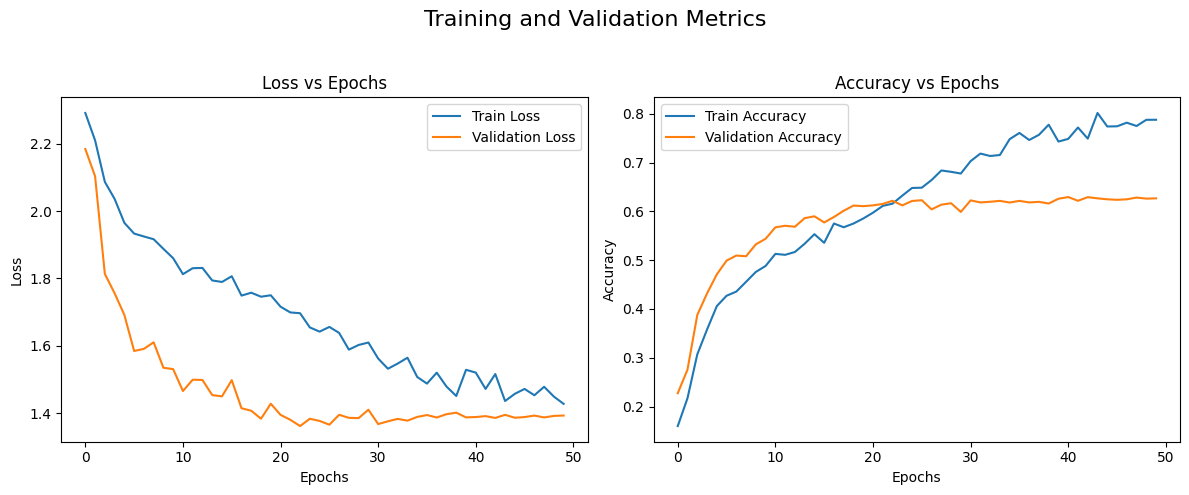

In [18]:
train_graphs(train_losses, train_accuracies, val_losses, val_accuracies)

In [19]:
test(model, testloader)

Test Loss: 1.2046, Test Accuracy: 0.6266


### 1D Learned

In [20]:
model = VisualTransformer(192, 12, 768, 9, 10, embedding="1d")
train_losses, train_accuracies, val_losses, val_accuracies = train(model, trainloader, valloader, 50)
torch.save(model, "./1d_encoding.pth")

Epoch 1/50


Train Loss: 2.3140, Train Accuracy: 0.1277, Val Loss: 2.2531, Val Accuracy: 0.1734
Epoch 2/50


Train Loss: 2.2524, Train Accuracy: 0.1788, Val Loss: 2.1882, Val Accuracy: 0.2076
Epoch 3/50


Train Loss: 2.1591, Train Accuracy: 0.2461, Val Loss: 1.9761, Val Accuracy: 0.3102
Epoch 4/50


Train Loss: 2.0882, Train Accuracy: 0.3073, Val Loss: 1.9055, Val Accuracy: 0.3660
Epoch 5/50


...

Train Loss: 1.4154, Train Accuracy: 0.8170, Val Loss: 1.2774, Val Accuracy: 0.6760
Epoch 47/50


Train Loss: 1.3936, Train Accuracy: 0.8266, Val Loss: 1.2703, Val Accuracy: 0.6798
Epoch 48/50


Train Loss: 1.4239, Train Accuracy: 0.7933, Val Loss: 1.2744, Val Accuracy: 0.6780
Epoch 49/50


Train Loss: 1.4498, Train Accuracy: 0.8136, Val Loss: 1.2762, Val Accuracy: 0.6816
Epoch 50/50


Train Loss: 1.3966, Train Accuracy: 0.8124, Val Loss: 1.2718, Val Accuracy: 0.6806


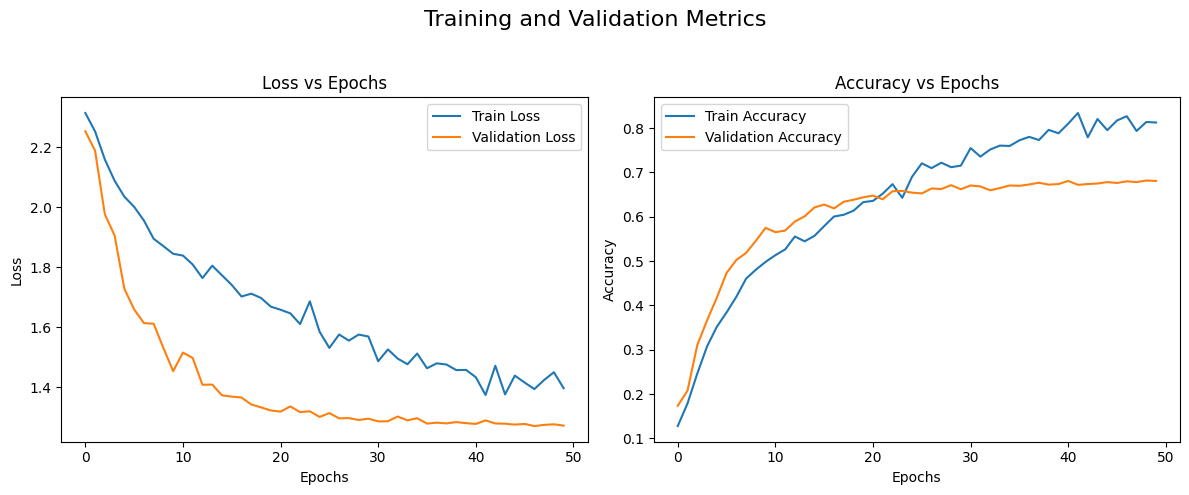

In [21]:
train_graphs(train_losses, train_accuracies, val_losses, val_accuracies)

In [22]:
test(model, testloader)

Test Loss: 1.0514, Test Accuracy: 0.6866


### 2D Learned

In [23]:
model = VisualTransformer(192, 12, 768, 9, 10, embedding="2d")
train_losses, train_accuracies, val_losses, val_accuracies = train(model, trainloader, valloader, 50)
# torch.save(model, "./2d_encoding.pth")

Epoch 1/50


Train Loss: 2.3285, Train Accuracy: 0.1151, Val Loss: 2.2570, Val Accuracy: 0.1574
Epoch 2/50


Train Loss: 2.2660, Train Accuracy: 0.1639, Val Loss: 2.2176, Val Accuracy: 0.1994
Epoch 3/50


Train Loss: 2.1767, Train Accuracy: 0.2387, Val Loss: 2.0096, Val Accuracy: 0.3148
Epoch 4/50


Train Loss: 2.1209, Train Accuracy: 0.2895, Val Loss: 1.9131, Val Accuracy: 0.3526
Epoch 5/50


...

Train Loss: 1.4913, Train Accuracy: 0.7606, Val Loss: 1.2935, Val Accuracy: 0.6624
Epoch 47/50


Train Loss: 1.4765, Train Accuracy: 0.7769, Val Loss: 1.2986, Val Accuracy: 0.6574
Epoch 48/50


Train Loss: 1.5070, Train Accuracy: 0.7590, Val Loss: 1.2962, Val Accuracy: 0.6624
Epoch 49/50


Train Loss: 1.5102, Train Accuracy: 0.7588, Val Loss: 1.2953, Val Accuracy: 0.6588
Epoch 50/50


Train Loss: 1.4427, Train Accuracy: 0.7959, Val Loss: 1.2974, Val Accuracy: 0.6586


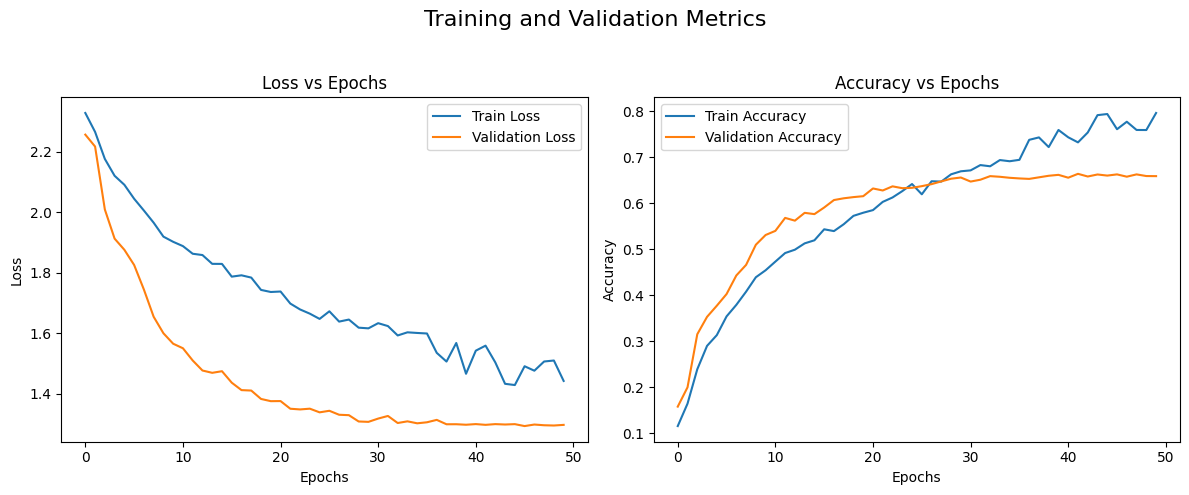

In [24]:
train_graphs(train_losses, train_accuracies, val_losses, val_accuracies)

In [25]:
test(model, testloader)

Test Loss: 1.0677, Test Accuracy: 0.6812


### Sinusoidal

In [26]:
model = VisualTransformer(192, 12, 768, 9, 10, embedding="sin")
train_losses, train_accuracies, val_losses, val_accuracies = train(model, trainloader, valloader, 50)
torch.save(model, "./sin_encoding.pth")

Epoch 1/50


Train Loss: 2.3260, Train Accuracy: 0.1174, Val Loss: 2.2552, Val Accuracy: 0.1778
Epoch 2/50


Train Loss: 2.2640, Train Accuracy: 0.1646, Val Loss: 2.1958, Val Accuracy: 0.2130
Epoch 3/50


Train Loss: 2.1082, Train Accuracy: 0.2955, Val Loss: 1.8107, Val Accuracy: 0.3880
Epoch 4/50


Train Loss: 2.0048, Train Accuracy: 0.3757, Val Loss: 1.7008, Val Accuracy: 0.4496
Epoch 5/50


...

Train Loss: 1.3456, Train Accuracy: 0.8561, Val Loss: 1.1348, Val Accuracy: 0.7440
Epoch 47/50


Train Loss: 1.4239, Train Accuracy: 0.8094, Val Loss: 1.1355, Val Accuracy: 0.7438
Epoch 48/50


Train Loss: 1.3701, Train Accuracy: 0.8373, Val Loss: 1.1373, Val Accuracy: 0.7408
Epoch 49/50


Train Loss: 1.3407, Train Accuracy: 0.8500, Val Loss: 1.1307, Val Accuracy: 0.7444
Epoch 50/50


Train Loss: 1.3880, Train Accuracy: 0.8216, Val Loss: 1.1302, Val Accuracy: 0.7454


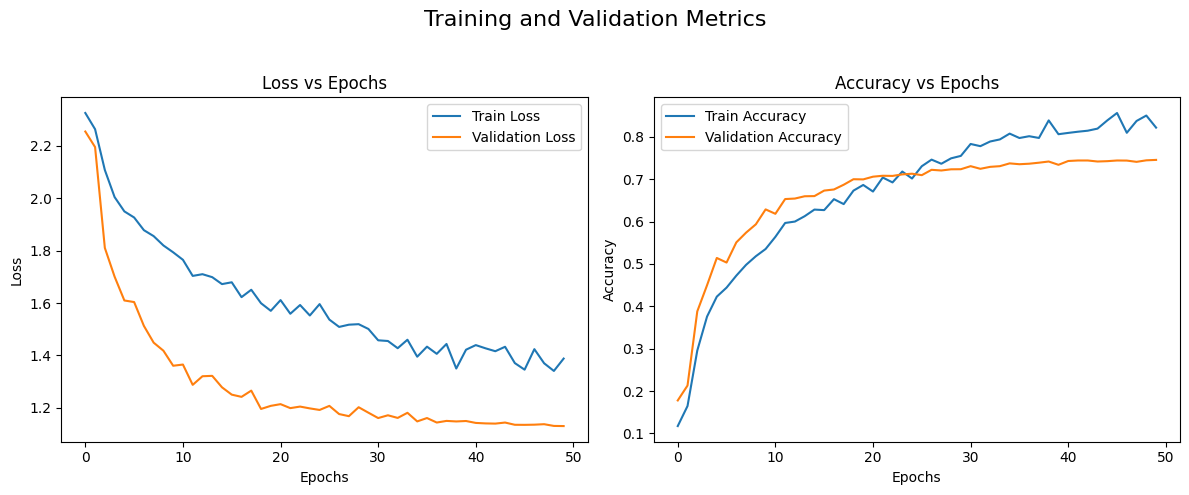

In [27]:
train_graphs(train_losses, train_accuracies, val_losses, val_accuracies)

In [28]:
test(model, testloader)

Test Loss: 0.9130, Test Accuracy: 0.7457


## Patch Sizes

### 8

In [29]:
model = VisualTransformer(192, 12, 768, 9, 10, patch_size=8)
train_losses, train_accuracies, val_losses, val_accuracies = train(model, trainloader, valloader, 50)
torch.save(model, "./patch_8.pth")

Epoch 1/50


Train Loss: 2.3385, Train Accuracy: 0.1070, Val Loss: 2.2756, Val Accuracy: 0.1354
Epoch 2/50


Train Loss: 2.2845, Train Accuracy: 0.1398, Val Loss: 2.2334, Val Accuracy: 0.1680
Epoch 3/50


Train Loss: 2.1417, Train Accuracy: 0.2642, Val Loss: 1.9261, Val Accuracy: 0.3496
Epoch 4/50


Train Loss: 2.0835, Train Accuracy: 0.3180, Val Loss: 1.8329, Val Accuracy: 0.3778
Epoch 5/50


...

Train Loss: 1.4321, Train Accuracy: 0.8035, Val Loss: 1.3505, Val Accuracy: 0.6440
Epoch 47/50


Train Loss: 1.4975, Train Accuracy: 0.7701, Val Loss: 1.3470, Val Accuracy: 0.6488
Epoch 48/50


Train Loss: 1.4819, Train Accuracy: 0.7779, Val Loss: 1.3454, Val Accuracy: 0.6488
Epoch 49/50


Train Loss: 1.4500, Train Accuracy: 0.8037, Val Loss: 1.3477, Val Accuracy: 0.6462
Epoch 50/50


Train Loss: 1.4434, Train Accuracy: 0.8010, Val Loss: 1.3482, Val Accuracy: 0.6444


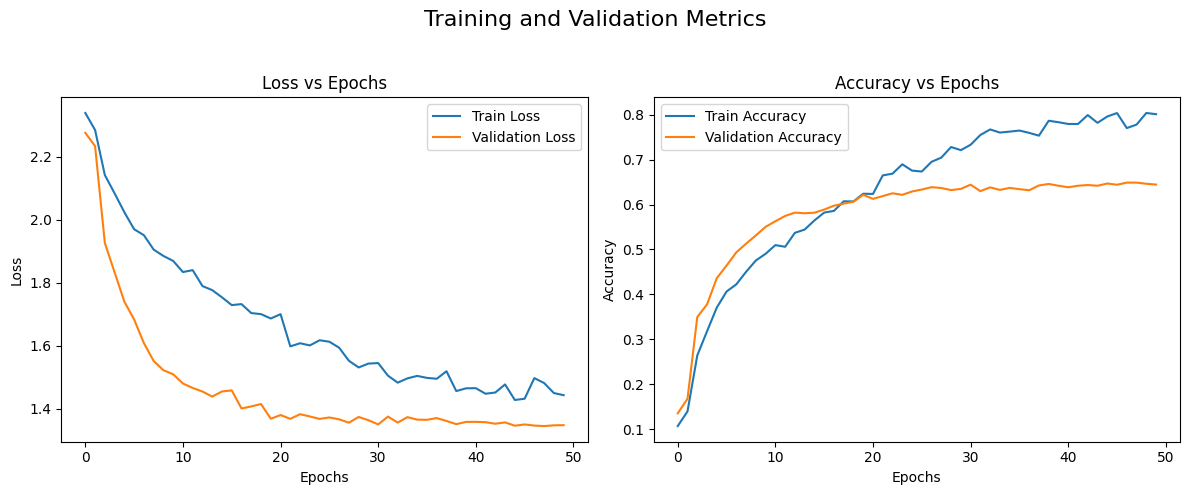

In [30]:
train_graphs(train_losses, train_accuracies, val_losses, val_accuracies)

In [31]:
test(model, testloader)

Test Loss: 1.1434, Test Accuracy: 0.6482


### 4

In [32]:
model = VisualTransformer(192, 12, 768, 9, 10, patch_size=4)
train_losses, train_accuracies, val_losses, val_accuracies = train(model, trainloader, valloader, 50)
torch.save(model, "./patch_4.pth")

Epoch 1/50


Train Loss: 2.3066, Train Accuracy: 0.1256, Val Loss: 2.2332, Val Accuracy: 0.1688
Epoch 2/50


Train Loss: 2.2459, Train Accuracy: 0.1792, Val Loss: 2.1683, Val Accuracy: 0.2076
Epoch 3/50


Train Loss: 2.1480, Train Accuracy: 0.2621, Val Loss: 1.9427, Val Accuracy: 0.3518
Epoch 4/50


Train Loss: 2.0701, Train Accuracy: 0.3283, Val Loss: 1.8171, Val Accuracy: 0.3948
Epoch 5/50


...

Train Loss: 1.4372, Train Accuracy: 0.8053, Val Loss: 1.2460, Val Accuracy: 0.6920
Epoch 47/50


Train Loss: 1.3487, Train Accuracy: 0.8404, Val Loss: 1.2496, Val Accuracy: 0.6914
Epoch 48/50


Train Loss: 1.4290, Train Accuracy: 0.8136, Val Loss: 1.2455, Val Accuracy: 0.6940
Epoch 49/50


Train Loss: 1.4153, Train Accuracy: 0.8232, Val Loss: 1.2438, Val Accuracy: 0.6934
Epoch 50/50


Train Loss: 1.3654, Train Accuracy: 0.8360, Val Loss: 1.2439, Val Accuracy: 0.6948


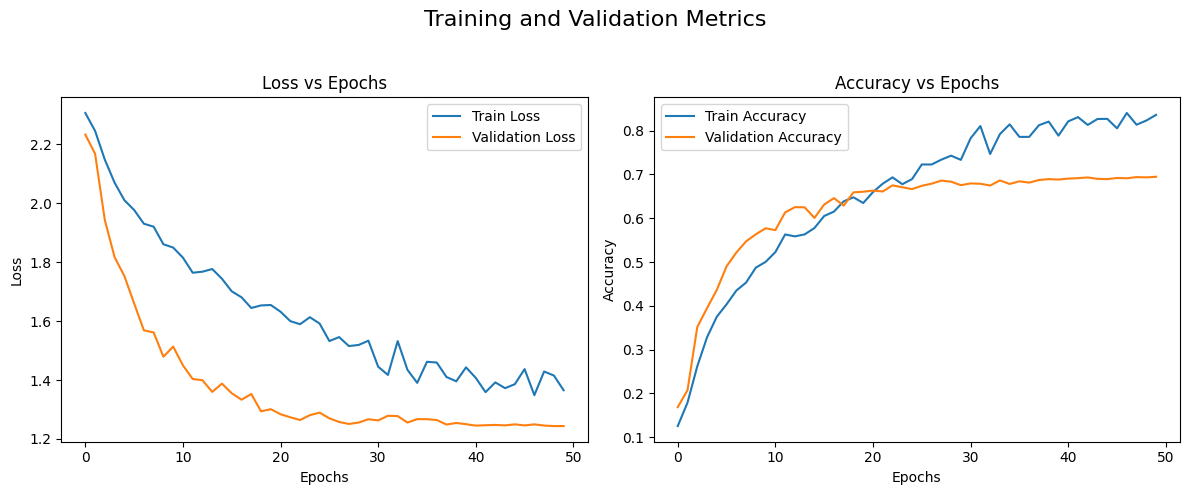

In [33]:
train_graphs(train_losses, train_accuracies, val_losses, val_accuracies)

In [34]:
test(model, testloader)

Test Loss: 1.0166, Test Accuracy: 0.6976


### 2

In [13]:
model = VisualTransformer(192, 12, 768, 9, 10, patch_size=2)
train_losses, train_accuracies, val_losses, val_accuracies = train(model, trainloader, valloader, 20)
torch.save(model, "./patch_2.pth")

Epoch 1/20


Train Loss: 2.2452, Train Accuracy: 0.1792, Val Loss: 2.1329, Val Accuracy: 0.2256
Epoch 2/20


Train Loss: 2.1906, Train Accuracy: 0.2204, Val Loss: 2.0989, Val Accuracy: 0.2420
Epoch 3/20


Train Loss: 2.1320, Train Accuracy: 0.2742, Val Loss: 1.9030, Val Accuracy: 0.3498
Epoch 4/20


Train Loss: 2.0525, Train Accuracy: 0.3440, Val Loss: 1.7603, Val Accuracy: 0.4356
Epoch 5/20


...

Train Loss: 1.7223, Train Accuracy: 0.5844, Val Loss: 1.3607, Val Accuracy: 0.6298
Epoch 17/20


Train Loss: 1.7059, Train Accuracy: 0.5946, Val Loss: 1.3462, Val Accuracy: 0.6370
Epoch 18/20


Train Loss: 1.6928, Train Accuracy: 0.6046, Val Loss: 1.3403, Val Accuracy: 0.6398
Epoch 19/20


Train Loss: 1.6830, Train Accuracy: 0.6156, Val Loss: 1.3285, Val Accuracy: 0.6456
Epoch 20/20


Train Loss: 1.6791, Train Accuracy: 0.6192, Val Loss: 1.3241, Val Accuracy: 0.6468


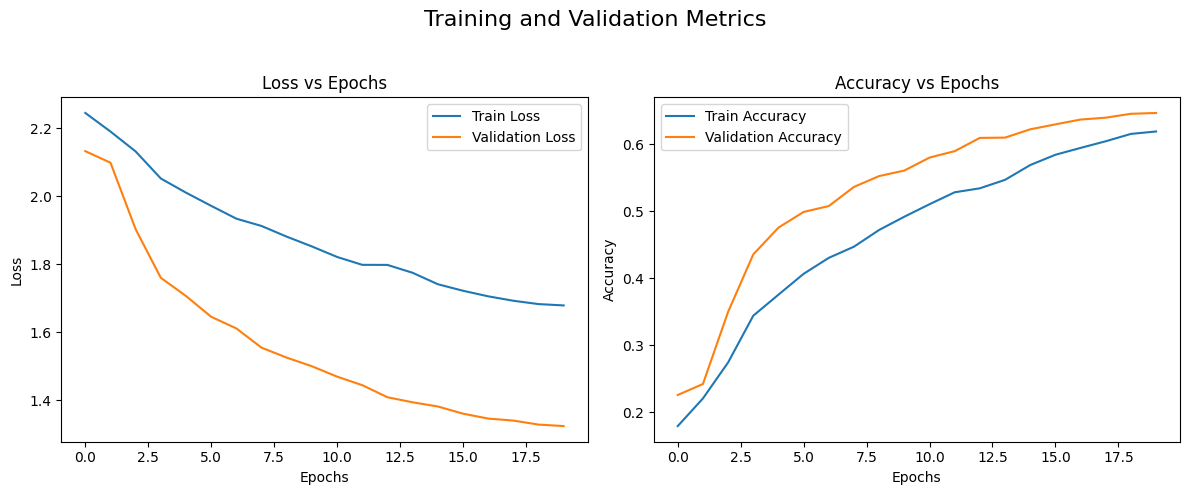

In [14]:
train_graphs(train_losses, train_accuracies, val_losses, val_accuracies)

In [15]:
test(model, testloader)

Test Loss: 1.1557, Test Accuracy: 0.6379
